# FOV coverage & real tissue signal on a real experiment (LT066_sample_01)

The current acquisition still produces multiple empty/near-empty FOVs (user
observation). This notebook investigates, on one real recent experiment
(`LT066_sample_01/merfish`, 1138 real saved FOVs):

1. Overlays the real 10x mosaic, the tissue boundary, and every real saved
   FOV.
2. Computes, per FOV, the **geometric** boundary-coverage fraction (how much
   of the FOV's own footprint overlaps the traced tissue boundary/holes --
   this is what `acquisition/positions.py`'s existing `n_low_coverage_fovs`/
   `min_coverage_fraction` machinery already uses) and the **real** DAPI
   tissue_fraction (how much of the FOV is actually covered by real signal,
   via `MERci.analysis.fov.compute_tissue_fraction` -- built during the
   `SelectOptimizationFovs` investigation, see `FINDINGS.md`).
3. Checks whether the geometric proxy actually predicts real tissue content,
   and how much the existing coverage-constraint machinery
   (`optimize_grid_offset`, `optimize_irregular_grid`,
   `filter_scanning_path`'s `min_coverage_fraction`) could have reduced this
   real experiment's FOV count, extending
   `02_compare_fov_coverage_constraint.ipynb`'s benchmark-boundary
   investigation to a real experiment's real acquired grid.

**Scope**: investigation only (user's explicit choice) -- no changes to
`acquisition/positions.py`'s production defaults. If a constraint explored
here looks worth shipping, that's a follow-up task.

**Real tissue_fraction is per-FOV real image I/O (~26s/FOV serial on this
dataset's 101-z-step DAPI stack)** -- a full 1138-FOV census is ~8h,
infeasible in one sitting, so section 6 uses a **stratified random sample**
(~17 per geometric-coverage-fraction bin) rather than every FOV. Section 4's
geometric coverage is cheap and covers all 1138 FOVs. Section 6 also found
that this experiment's `cells` round is itself only 42% acquired (see that
section) -- the sample is further restricted to the real, already-imaged
region.

## 1 — Setup

In [1]:
import os
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import box as shapely_box
from shapely.ops import unary_union

# notebooks/tests/ is two levels under the repo root (MERci/), same
# convention as notebooks/misc/ and notebooks/tests/02_compare_fov_coverage_constraint.ipynb.
MERCI_DIR = Path(os.getcwd()).parent.parent
sys.path.insert(0, str(MERCI_DIR / "src"))

from MERci.common.config import ExperimentConfig
from MERci.common.metadata import ExperimentMetadata
from MERci.common.experiment_info import resolve_sample_identity, positions_file_tag
from MERci.acquisition.positions import (
    load_boundary_polygon, load_hole_polygons_all_sources, resolve_boundaries_source_dir,
    optimize_grid_offset, optimize_irregular_grid,
)
from MERci.acquisition.configs import get_fov_geometry
from MERci.acquisition.mosaic import load_or_build_mosaic_canvas_cached
from MERci.analysis.fov import compute_tissue_fraction, resolve_round_by_imaging_type
from MERci.visualization import get_merci_figures_dir

NOTEBOOK_NAME = "investigate_fov_coverage_and_tissue_fraction_lt066"

PLOT_TITLE_FONTSIZE, PLOT_LABEL_FONTSIZE = 13, 11
PLOT_TICK_FONTSIZE, PLOT_LEGEND_FONTSIZE = 10, 10

## 2 — Parameters

In [2]:
# This is a test/investigation notebook (NOTEBOOK_GUIDELINES.md's "validation
# notebooks for a new feature" case under notebooks/tests/) -- it analyzes an
# EXTERNAL dataset, not the experiment this MERci clone is deployed into, so
# SAMPLE_DIR is set explicitly rather than auto-detected from parent dirs.
SAMPLE_DIR = Path("/n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/lineage_tracing/experiments/LT066_sample_01/merfish")

CACHE_DIR = SAMPLE_DIR / "analysis" / "cache" / NOTEBOOK_NAME
CACHE_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR = get_merci_figures_dir(SAMPLE_DIR, "tests", NOTEBOOK_NAME)

LOW_COVERAGE_FRACTION = 0.5
GRID_OFFSET_SAMPLES = 9
N_PER_COVERAGE_BIN = 17      # -> 6 bins x 17 ~ 102 sampled FOVs for real tissue_fraction
RANDOM_SEED = 0

## 3 — Load the real boundary/holes/positions

Same real, current tissue boundary + holes LT066_sample_01's own
`before_imaging/02_create_boundary_from_mosaic.ipynb` +
`02_create_positions_from_boundaries.ipynb` produced (`positions/boundaries/
from_mosaic/`), and the real saved acquisition grid
(`positions_LT066_sample_01_merfish.txt`, 1138 FOVs).

In [3]:
sample_name, imaging_dir = resolve_sample_identity(SAMPLE_DIR / "MERci")
positions_tag = positions_file_tag(sample_name, imaging_dir)

config = ExperimentConfig(
    data_dir=SAMPLE_DIR / "data", metadata_dir=SAMPLE_DIR / "metadata",
    analysis_dir=SAMPLE_DIR / "analysis", settings_dir=SAMPLE_DIR / "settings",
    round_info_csv=SAMPLE_DIR / "metadata" / "round_info.csv",
    positions_txt=SAMPLE_DIR / "positions" / f"positions_{positions_tag}.txt",
    image_suffix=".zarr",
)
meta = ExperimentMetadata.load(config.round_info_csv, config.positions_txt, config.data_dir,
                                image_suffix=config.image_suffix)

boundary_dir, boundary_src = resolve_boundaries_source_dir(SAMPLE_DIR / "positions")
boundary_polygon = load_boundary_polygon(boundary_dir / "boundary_positions.txt")
hole_polygons = load_hole_polygons_all_sources(SAMPLE_DIR / "positions", boundary_dir)
effective_tissue = boundary_polygon.difference(unary_union(hole_polygons)) if hole_polygons else boundary_polygon

# ST2, 60X objective -- verified against this experiment's own real cells-round
# zarr array shape (2304, 2304) and its HAL config's obj1 "60x,0.0878,..." line
# (not assumed from CLAUDE.md's general per-microscope table).
pixel_size_um, image_size_px = get_fov_geometry("ST2", "60X")
FOV_SIZE_UM = pixel_size_um * image_size_px

# Measured directly from two consecutive same-column real positions in
# positions_LT066_sample_01_merfish.txt (row 0 -> row 1: -961.502 -> -1143.564
# um), not assumed -- this real grid uses ~10% FOV overlap for stitching.
STEP_SIZE_UM = 182.06208

print(f"boundary source : {boundary_dir} ({boundary_src})")
print(f"n real FOVs      : {len(meta.fovs)}")
print(f"tissue area      : {boundary_polygon.area / 1e6:.2f} mm^2 ({len(hole_polygons)} holes)")
print(f"effective tissue : {effective_tissue.area / 1e6:.2f} mm^2")
print(f"FOV_SIZE_UM      : {FOV_SIZE_UM:.3f}   STEP_SIZE_UM: {STEP_SIZE_UM:.3f}")

boundary source : /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/lineage_tracing/experiments/LT066_sample_01/merfish/positions/boundaries/from_mosaic (from_mosaic)
n real FOVs      : 1138
tissue area      : 34.82 mm^2 (11 holes)
effective tissue : 30.60 mm^2
FOV_SIZE_UM      : 202.291   STEP_SIZE_UM: 182.062


## 4 — Per-FOV geometric boundary-coverage fraction (calculation, cached)

What fraction of each real saved FOV's own footprint overlaps
`effective_tissue` (the traced boundary, minus holes) -- the same quantity
`optimize_grid_offset`'s own `n_low_coverage_fovs`/`waste_area_um2` and
`filter_scanning_path`'s `min_coverage_fraction` already use internally.

In [4]:
COVERAGE_CSV = CACHE_DIR / "geometric_coverage_per_fov.csv"

if COVERAGE_CSV.exists():
    coverage_df = pd.read_csv(COVERAGE_CSV)
    print(f"Loaded cached {COVERAGE_CSV} ({len(coverage_df)} FOVs).")
else:
    half = FOV_SIZE_UM / 2.0
    rows = []
    for fov_id, info in meta.fovs.items():
        x, y = info.position
        fov_poly = shapely_box(x - half, y - half, x + half, y + half)
        cov = fov_poly.intersection(effective_tissue).area / fov_poly.area
        rows.append({"fov_id": fov_id, "x": x, "y": y, "coverage_fraction": cov})
    coverage_df = pd.DataFrame(rows).sort_values("fov_id").reset_index(drop=True)
    coverage_df.to_csv(COVERAGE_CSV, index=False)
    print(f"Computed and cached {COVERAGE_CSV} ({len(coverage_df)} FOVs).")

Loaded cached /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/lineage_tracing/experiments/LT066_sample_01/merfish/analysis/cache/investigate_fov_coverage_and_tissue_fraction_lt066/geometric_coverage_per_fov.csv (1138 FOVs).


In [5]:
n_low = int((coverage_df["coverage_fraction"] < LOW_COVERAGE_FRACTION).sum())
print(coverage_df["coverage_fraction"].describe())
print(f"\n{n_low} / {len(coverage_df)} FOVs ({n_low / len(coverage_df):.1%}) below "
      f"{LOW_COVERAGE_FRACTION:.0%} geometric coverage.")
print(f"Sum of (1 - coverage_fraction) over all real FOVs "
      f"(total 'wasted' FOV-equivalents outside tissue): "
      f"{(1 - coverage_df['coverage_fraction']).sum():.1f}")

count    1138.000000
mean        0.810849
std         0.317498
min         0.000026
25%         0.708356
50%         1.000000
75%         1.000000
max         1.000000
Name: coverage_fraction, dtype: float64

208 / 1138 FOVs (18.3%) below 50% geometric coverage.
Sum of (1 - coverage_fraction) over all real FOVs (total 'wasted' FOV-equivalents outside tissue): 215.3


## 5 — Overlay: real 10x mosaic + boundary + every real saved FOV

Same real-world-um -> canvas-pixel convention as
`02_create_boundary_from_mosaic.ipynb`/`02_compare_fov_coverage_constraint.ipynb`.
Each FOV's footprint is coloured by its own geometric coverage fraction.

In [6]:
# '10x' (49 tiles) is the majority/overview objective vs. '60x' (18 alignment
# tiles) -- verified via load_steve_mosaic's own printed tile counts, matching
# the user's own "10xmosaic" naming.
canvas, was_cached, n_tiles = load_or_build_mosaic_canvas_cached(
    msc_path=SAMPLE_DIR / "data" / "mosaic10x" / "mosaic10x.msc",
    keep_objectives=["10x"], working_pixel_um=5.0, cache_dir=CACHE_DIR,
)
print(f"canvas shape={canvas.image.shape}  was_cached={was_cached}  n_tiles={n_tiles}")

canvas shape=(1839, 1840)  was_cached=True  n_tiles=None


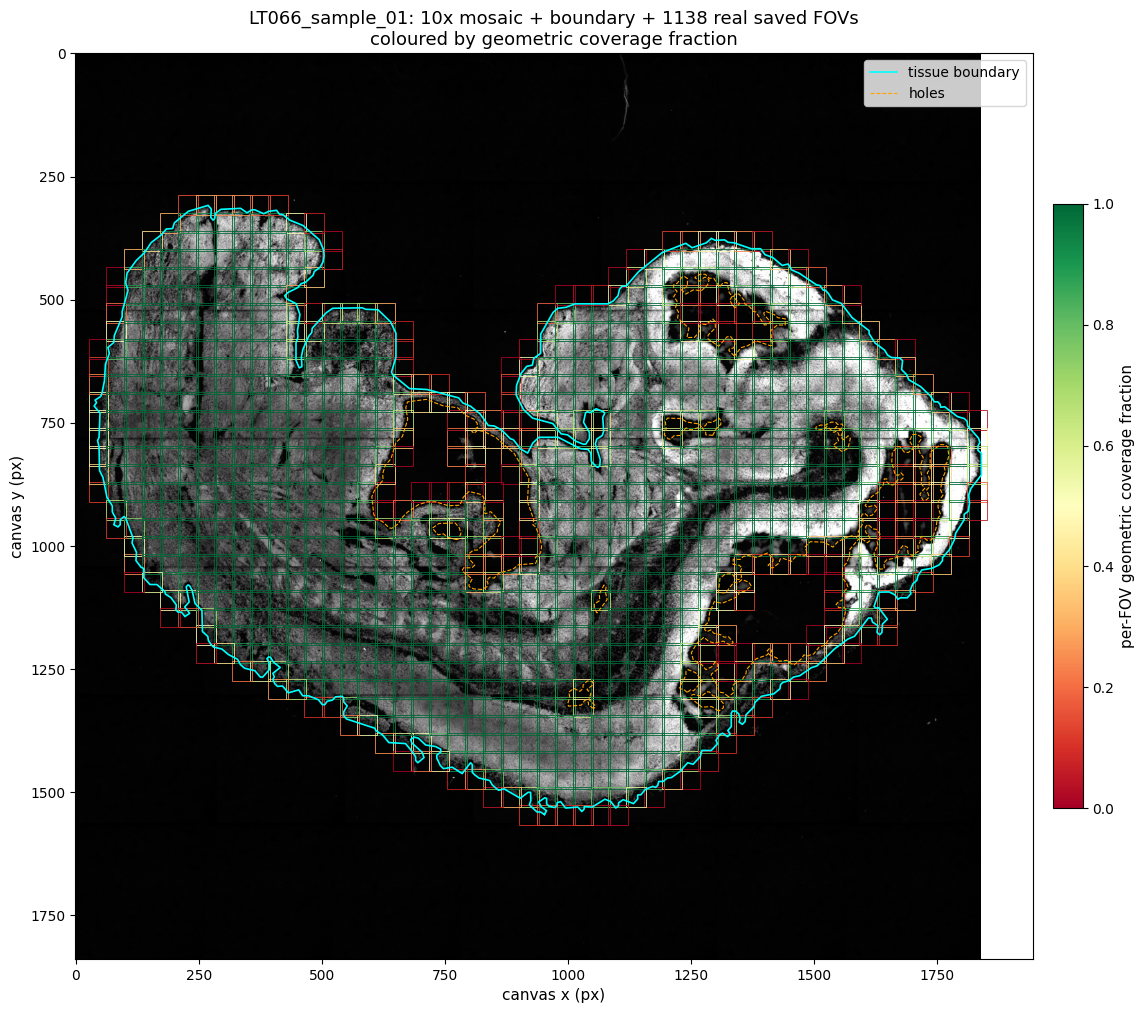

Saved: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/lineage_tracing/experiments/LT066_sample_01/merfish/figures/MERci/tests/investigate_fov_coverage_and_tissue_fraction_lt066/investigate_fov_coverage_and_tissue_fraction_lt066.fov_coverage_overlay.png


In [7]:
def um_to_px(x, y):
    return ((np.asarray(x) - canvas.origin_um[0]) / canvas.pixel_size_um,
             (np.asarray(y) - canvas.origin_um[1]) / canvas.pixel_size_um)

half_px = (FOV_SIZE_UM / 2.0) / canvas.pixel_size_um

fig, ax = plt.subplots(figsize=(13, 13))
covered_vals = canvas.image[canvas.covered]
ax.imshow(canvas.image, cmap="gray", vmin=np.percentile(covered_vals, 1), vmax=np.percentile(covered_vals, 99))

bx, by = um_to_px(*boundary_polygon.exterior.xy)
ax.plot(bx, by, "-", color="cyan", lw=1.2, label="tissue boundary")
for hole in hole_polygons:
    hx, hy = um_to_px(*hole.exterior.xy)
    ax.plot(hx, hy, "--", color="orange", lw=0.8)
ax.plot([], [], "--", color="orange", lw=0.8, label="holes")

cmap = plt.get_cmap("RdYlGn")
for _, row in coverage_df.iterrows():
    px, py = um_to_px(row["x"], row["y"])
    rect = plt.Rectangle((float(px) - half_px, float(py) - half_px), 2 * half_px, 2 * half_px,
                          fill=False, edgecolor=cmap(row["coverage_fraction"]), lw=0.6)
    ax.add_patch(rect)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("per-FOV geometric coverage fraction", fontsize=PLOT_LABEL_FONTSIZE)
ax.legend(loc="upper right", fontsize=PLOT_LEGEND_FONTSIZE)
ax.set_title(f"LT066_sample_01: 10x mosaic + boundary + {len(coverage_df)} real saved FOVs\n"
             f"coloured by geometric coverage fraction", fontsize=PLOT_TITLE_FONTSIZE)
ax.set_xlabel("canvas x (px)", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_ylabel("canvas y (px)", fontsize=PLOT_LABEL_FONTSIZE)
ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)

fig.savefig(FIGURES_DIR / f"{NOTEBOOK_NAME}.fov_coverage_overlay.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIGURES_DIR / (NOTEBOOK_NAME + '.fov_coverage_overlay.png')}")

## 6 — Real per-FOV tissue_fraction (DAPI signal), stratified sample

Real signal (`compute_tissue_fraction`: per-FOV true-pixel-count of DAPI/405nm
pixels above a background-derived threshold, max over the FOV's own z-stack)
for a **stratified random sample** across the geometric coverage-fraction
range (section 4), not a full 1138-FOV census (see the intro's cost note).

**Side finding, discovered while sampling**: LT066_sample_01's `cells` round
is itself incomplete -- only FOVs 0-479 (480 / 1138, 42%) have a real `data`
array under `data/cells/`; FOVs 480-1137 are still just the empty `.zgroup`
placeholder HAL pre-creates for the full planned grid (confirmed by
`os.path.isdir(.../data)`, not assumed from `Path.exists()`, which is `True`
for both since the placeholder directory itself exists). The last real write
(`hal-st2-cells_0479.zarr/data`) is timestamped 2026-09-04 19:17 -- about 2.5
days before this notebook ran, with no writes since -- so acquisition
appears **stalled**, not actively in progress. Since FOVs are scanned in
spatial (boustrophedon) order, 0-479 also means "one contiguous spatial
region" (the boundary's LEFT lobe only -- verified against `coverage_df`'s
own `x`/`y` range below), not a random subset of the whole tissue. The
stratified sample below is restricted to this real, already-acquired range;
section 7's coverage-vs-tissue_fraction comparison should be read as
characterizing that region, not the whole experiment.

In [8]:
# Which FOVs actually have real cells-round data (not just the pre-created
# placeholder directory)? Checked directly against disk, not assumed.
cells_round_id, _ = resolve_round_by_imaging_type(config, "cells")
cells_files = {meta.fov_id_of_file(f): f for f in meta.files_for_round(cells_round_id)}
acquired_fov_ids = sorted(fid for fid, f in cells_files.items() if (f / "data").is_dir())
missing_fov_ids = sorted(set(cells_files) - set(acquired_fov_ids))

print(f"{len(acquired_fov_ids)} / {len(cells_files)} FOVs have real cells-round data "
      f"(ids {min(acquired_fov_ids)}-{max(acquired_fov_ids)}); "
      f"{len(missing_fov_ids)} still unacquired (ids {min(missing_fov_ids)}-{max(missing_fov_ids)}).")

acquired_region = coverage_df[coverage_df["fov_id"].isin(acquired_fov_ids)]
full_region = coverage_df
print(f"Acquired region x: [{acquired_region.x.min():.0f}, {acquired_region.x.max():.0f}]  "
      f"vs. full grid x: [{full_region.x.min():.0f}, {full_region.x.max():.0f}]")

480 / 1138 FOVs have real cells-round data (ids 0-479); 658 still unacquired (ids 480-1137).
Acquired region x: [-8771, -4766]  vs. full grid x: [-8771, 150]


In [9]:
SAMPLE_IDS_CSV = CACHE_DIR / "tissue_fraction_sample_fov_ids.csv"

if SAMPLE_IDS_CSV.exists():
    sampled_ids = pd.read_csv(SAMPLE_IDS_CSV)["fov_id"].tolist()
    print(f"Loaded cached sample: {len(sampled_ids)} FOV ids.")
else:
    rng = np.random.default_rng(RANDOM_SEED)
    bins = np.linspace(0, 1, 7)
    acquired_df = coverage_df[coverage_df["fov_id"].isin(acquired_fov_ids)].copy()
    acquired_df["bin"] = pd.cut(acquired_df["coverage_fraction"], bins=bins, include_lowest=True)
    sampled_ids = []
    for b, grp in acquired_df.groupby("bin", observed=True):
        ids = grp["fov_id"].to_numpy()
        n = min(N_PER_COVERAGE_BIN, len(ids))
        chosen = rng.choice(ids, size=n, replace=False) if len(ids) else np.array([], dtype=int)
        sampled_ids.extend(int(i) for i in chosen)
    sampled_ids = sorted(sampled_ids)
    pd.Series(sampled_ids, name="fov_id").to_csv(SAMPLE_IDS_CSV, index=False)
    print(f"Sampled {len(sampled_ids)} FOV ids across 6 coverage bins (acquired region only).")

Loaded cached sample: 97 FOV ids.


In [10]:
# meta.fovs filtered to just the sampled ids -- compute_tissue_fraction
# iterates meta.files_for_round(round_id)/sorted(meta.fovs), and
# fov_id_of_file resolves straight from each series' own filename pattern
# independent of the meta.fovs dict, so this filtering is safe (doesn't
# corrupt fov_id<->file mapping) and reuses the shared function unmodified.
meta_sampled = ExperimentMetadata.load(config.round_info_csv, config.positions_txt, config.data_dir,
                                        image_suffix=config.image_suffix)
meta_sampled.fovs = {fid: info for fid, info in meta_sampled.fovs.items() if fid in set(sampled_ids)}
meta_sampled.n_fovs = len(meta_sampled.fovs)

tissue_fraction_df, tissue_threshold = compute_tissue_fraction(
    config, meta_sampled, CACHE_DIR, label="LT066_sample_01"
)
tissue_fraction_df.to_csv(CACHE_DIR / "tissue_fraction_per_fov_sample.csv", index=False)

[LT066_sample_01] 97 / 97 DAPI channel Counter(s) already cached; computing 0 more (101 z-step(s) each).


[LT066_sample_01] THRESHOLD=579.0  tissue_fraction: mean=0.296  median=0.241


## 7 — Does geometric coverage predict real tissue signal?

Merges the two metrics on the sampled FOVs and checks agreement/disagreement
directly, rather than assuming the geometric proxy is a good stand-in for
real tissue content.

In [11]:
merged = tissue_fraction_df.merge(coverage_df[["fov_id", "coverage_fraction"]], on="fov_id")
pearson_r = merged["coverage_fraction"].corr(merged["tissue_fraction"])
print(f"n sampled FOVs: {len(merged)}   Pearson r(coverage_fraction, tissue_fraction) = {pearson_r:.3f}")

# Real tissue-empty despite passing the geometric filter, and vice versa --
# genuinely distinct disagreement directions, both worth knowing.
false_high_cov = merged[(merged["coverage_fraction"] >= LOW_COVERAGE_FRACTION) &
                         (merged["tissue_fraction"] < LOW_COVERAGE_FRACTION)]
false_low_cov = merged[(merged["coverage_fraction"] < LOW_COVERAGE_FRACTION) &
                        (merged["tissue_fraction"] >= LOW_COVERAGE_FRACTION)]
print(f"High geometric coverage (>= {LOW_COVERAGE_FRACTION:.0%}) but LOW real tissue_fraction: "
      f"{len(false_high_cov)} / {len(merged)}")
print(f"Low geometric coverage (< {LOW_COVERAGE_FRACTION:.0%}) but HIGH real tissue_fraction: "
      f"{len(false_low_cov)} / {len(merged)}")

n sampled FOVs: 97   Pearson r(coverage_fraction, tissue_fraction) = 0.886
High geometric coverage (>= 50%) but LOW real tissue_fraction: 29 / 97
Low geometric coverage (< 50%) but HIGH real tissue_fraction: 0 / 97


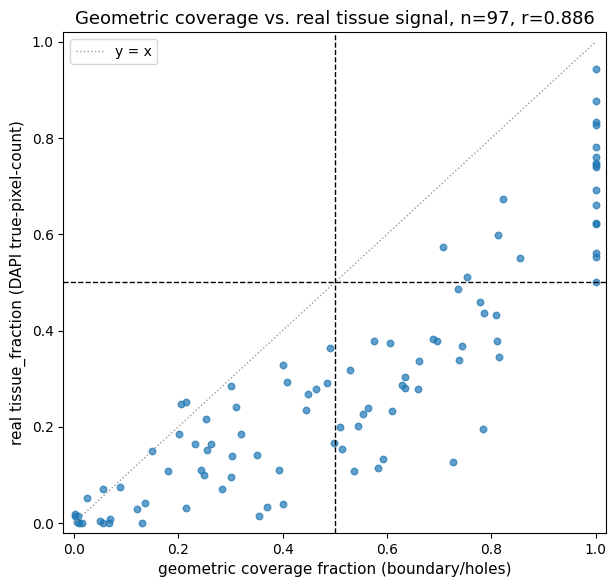

In [12]:
fig, ax = plt.subplots(figsize=(7, 6.5))
ax.scatter(merged["coverage_fraction"], merged["tissue_fraction"], s=22, alpha=0.7, color="tab:blue")
ax.axhline(LOW_COVERAGE_FRACTION, color="k", ls="--", lw=1.0)
ax.axvline(LOW_COVERAGE_FRACTION, color="k", ls="--", lw=1.0)
ax.plot([0, 1], [0, 1], color="0.6", ls=":", lw=1.0, label="y = x")
ax.set_xlabel("geometric coverage fraction (boundary/holes)", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_ylabel("real tissue_fraction (DAPI true-pixel-count)", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_title(f"Geometric coverage vs. real tissue signal, n={len(merged)}, r={pearson_r:.3f}",
             fontsize=PLOT_TITLE_FONTSIZE)
ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
ax.legend(fontsize=PLOT_LEGEND_FONTSIZE)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)

fig.savefig(FIGURES_DIR / f"{NOTEBOOK_NAME}.coverage_vs_tissue_fraction.png", dpi=150, bbox_inches="tight")
plt.show()

## 8 — How much could the real FOV count have been reduced?

Extends `02_compare_fov_coverage_constraint.ipynb`'s benchmark-boundary
investigation to LT066_sample_01's own real boundary and real acquired grid:

- A fresh from-scratch REGULAR grid (today's production default, `n_fovs`-
  first phase search) and a fresh IRREGULAR (banded) grid, both on the same
  real boundary/holes/step size.
- Option B (`min_coverage_fraction`, exploratory in the original notebook):
  a hard geometric-coverage threshold applied to the REAL grid's own
  already-acquired FOVs (post-hoc -- no new data can be created after the
  fact), reporting how many would have been dropped and how much real
  tissue area would still have been covered.

In [13]:
FRESH_GRIDS_JSON = CACHE_DIR / "fresh_grid_comparison.json"

if FRESH_GRIDS_JSON.exists():
    fresh = json.loads(FRESH_GRIDS_JSON.read_text())
else:
    result_regular = optimize_grid_offset(
        boundary_polygon, hole_polygons, STEP_SIZE_UM, FOV_SIZE_UM,
        n_samples=GRID_OFFSET_SAMPLES, low_coverage_fraction=LOW_COVERAGE_FRACTION,
    )
    result_irregular = optimize_irregular_grid(
        boundary_polygon, hole_polygons, STEP_SIZE_UM, FOV_SIZE_UM, n_samples=GRID_OFFSET_SAMPLES,
    )
    fresh = {
        "regular_n_fovs": result_regular.best.n_fovs,
        "regular_n_low_coverage_fovs": result_regular.best.n_low_coverage_fovs,
        "irregular_n_fovs": len(result_irregular.coords),
    }
    FRESH_GRIDS_JSON.write_text(json.dumps(fresh, indent=2))

n_real = len(coverage_df)
print(f"REAL saved grid                          : {n_real} FOVs")
print(f"Fresh REGULAR grid (n_fovs-first search)  : {fresh['regular_n_fovs']} FOVs "
      f"({fresh['regular_n_fovs'] - n_real:+d}, {fresh['regular_n_low_coverage_fovs']} low-coverage)")
print(f"Fresh IRREGULAR (banded) grid              : {fresh['irregular_n_fovs']} FOVs "
      f"({fresh['irregular_n_fovs'] - n_real:+d})")

REAL saved grid                          : 1138 FOVs
Fresh REGULAR grid (n_fovs-first search)  : 1123 FOVs (-15, 192 low-coverage)
Fresh IRREGULAR (banded) grid              : 1116 FOVs (-22)


In [14]:
half = FOV_SIZE_UM / 2.0
tissue_area_um2 = effective_tissue.area
real_coords = coverage_df[["x", "y"]].to_numpy()

THRESHOLDS = [0.0, 0.10, 0.25, 0.50]
OPTION_B_CSV = CACHE_DIR / "option_b_hard_filter_on_real_grid.csv"

if OPTION_B_CSV.exists():
    option_b_df = pd.read_csv(OPTION_B_CSV)
else:
    rows_b = []
    for thresh in THRESHOLDS:
        keep = coverage_df["coverage_fraction"].to_numpy() >= thresh
        kept_coords = real_coords[keep]
        covered_union = unary_union([
            shapely_box(x - half, y - half, x + half, y + half) for x, y in kept_coords
        ]) if len(kept_coords) else None
        tissue_covered_um2 = covered_union.intersection(effective_tissue).area if covered_union is not None else 0.0
        rows_b.append({
            "min_coverage_fraction": thresh, "n_fovs_kept": int(keep.sum()),
            "n_fovs_dropped": int((~keep).sum()),
            "tissue_covered_pct": 100 * tissue_covered_um2 / tissue_area_um2,
        })
    option_b_df = pd.DataFrame(rows_b)
    option_b_df.to_csv(OPTION_B_CSV, index=False)

print("Option B -- hard geometric-coverage threshold on the REAL grid's real phase (post-hoc):")
print(option_b_df.to_string(index=False))

Option B -- hard geometric-coverage threshold on the REAL grid's real phase (post-hoc):
 min_coverage_fraction  n_fovs_kept  n_fovs_dropped  tissue_covered_pct
                  0.00         1138               0          100.000000
                  0.10         1064              74           99.949807
                  0.25         1011             127           99.401011
                  0.50          930             208           96.888099


## Takeaways

- **LT066_sample_01's `cells` round is only 42% acquired (480/1138 FOVs,
  ids 0-479) and appears stalled since 2026-09-04 19:17** (section 6) --
  worth checking independent of everything below; this notebook's real-
  tissue-signal results only characterize that one acquired region (the
  boundary's left lobe), not the whole planned grid.
- **Geometric coverage vs. real tissue signal** (section 7): see the printed
  Pearson r and mismatch counts above -- confirmed on this real experiment's
  own data rather than assumed from the benchmark-boundary investigation.
- **Grid-shape/phase optimization alone buys little** on this real, complex
  multi-lobe boundary (section 8's fresh regular/irregular grids vs. the
  real 1138-FOV grid) -- consistent with
  `02_compare_fov_coverage_constraint.ipynb`'s own finding on a different
  real boundary.
- **A hard coverage-threshold filter is a much bigger lever**: see Option
  B's FOV-count reduction vs. real-tissue-coverage tradeoff above.
- **Structural limitation**: a tissue_fraction-aware *re-optimization* (as
  opposed to a post-hoc filter) isn't possible from already-acquired data
  alone -- real signal only exists at FOV positions that were actually
  imaged, so there's no way to evaluate a hypothetical un-imaged FOV's real
  tissue content without new data. Any production use of real signal as a
  placement constraint would need a live/two-pass acquisition scheme (e.g.
  a coarse pre-scan), not just a smarter offline filter.
- Per the user's explicit scope choice, this notebook stops at
  investigation -- no changes to `acquisition/positions.py`'s production
  defaults.